# 02 — Environment Rollout Diagnostics (Plots)

Goal: run controlled rollouts and plot:
- SoC trajectory (bounds + dynamics)
- P_req vs P_applied (clipping visibility)
- planned vs applied power
- DA vs ID prices
- DA availability step function
- reward decomposition (profit_norm vs carbon_penalty_norm)

# 0. Imports + Env Factory

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from battery_env import BatteryEnv
import env_config

pd.set_option("display.max_columns", 200)

def make_env(seed=123, publish_hour=12, episode_days=5, randomize_init_soc=True):
    env = BatteryEnv(
        config=env_config,
        publish_hour=publish_hour,
        episode_days=episode_days,
        randomize_init_soc=randomize_init_soc,
        seed=seed,
    )
    return env

env = make_env(seed=123, episode_days=5, randomize_init_soc=True)
obs, info = env.reset(seed=123)
print("obs_len:", len(obs), "info:", info)

S_profit (DA+ID + Deg, £): 67.56119249999998
S_carbon (monetised, £): 4.756983517337498
obs_len: 103 info: {'start_day': '2023-03-07', 'publish_hour': 12, 'episode_days': 5, 'init_soc': 0.5729407452992574}


## 1. Rollout runner → DataFrame

In [2]:
import pandas as pd
import numpy as np

def collect_steps(env, n_steps, policy_fn, seed=123):
    """Runs the environment for n_steps using a specific policy and saves data to a DataFrame."""
    obs, info = env.reset(seed=seed)
    rows = []
    
    for t in range(n_steps):
        action = policy_fn(env, obs, t)
        obs, rew, term, trunc, info = env.step(action)
        done = term or trunc
        
        # 1. Safely extract Degradation Cost (Fallback math included just in case)
        deg_cost = info.get("Degradation_Cost_GBP", None)
        if deg_cost is None:
            # Fallback if it wasn't added to info dict
            starting_soc = info["soc"] - info["delta_soc"]
            stress = 1.0 + env.deg_alpha * (starting_soc - 0.5)**2
            deg_cost = env.deg_kappa * abs(info["P_applied_MW"]) * env.dt_hours * stress
            
        # 2. Extract profits
        da_profit = info.get("Planned_Profit", 0.0)
        id_profit = info.get("Intraday_Profit", 0.0)
        
        # 3. Build the row dictionary
        row = {
            "t": t,
            "reward": float(rew),
            "soc": info["soc"],
            "DA_Profit": da_profit,
            "ID_Profit": id_profit,
            "Degradation_Cost": deg_cost,
            "Net_Profit": (da_profit + id_profit) - deg_cost
        }
        rows.append(row)
        if done:
            break
            
    return pd.DataFrame(rows)

## 2. Policies

In [3]:
def policy_random(env, obs, t, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    a = env.action_space.sample()
    return np.array(a, dtype=np.int64)

def policy_do_nothing(env, obs, t):
    mid = env.n_power_levels // 2
    return np.array([mid, mid, 0], dtype=np.int64)

def policy_force_extremes(env, obs, t):
    # alternate charge/discharge to trigger clipping and SoC movement
    charge_idx = 0
    discharge_idx = env.n_power_levels - 1
    plan_idx = env.n_power_levels // 2
    plan_slot = (t % 48)
    dispatch = charge_idx if (t % 2 == 0) else discharge_idx
    return np.array([dispatch, plan_idx, plan_slot], dtype=np.int64)

## 3. Run 3 Rollouts

In [4]:
rng = np.random.default_rng(123)

df_rand = collect_steps(env, n_steps=300, policy_fn=lambda e,o,t: policy_random(e,o,t,rng=rng), seed=123)
df_zero = collect_steps(env, n_steps=300, policy_fn=policy_do_nothing, seed=123)
df_ext  = collect_steps(env, n_steps=300, policy_fn=policy_force_extremes, seed=123)

print("rand steps:", len(df_rand), "zero steps:", len(df_zero), "ext steps:", len(df_ext))
df_rand.head()

rand steps: 240 zero steps: 240 ext steps: 240


,t,reward,soc,DA_Profit,ID_Profit,Degradation_Cost,Net_Profit
0,0,0.000000,0.572941,0.0,0.000000,0.000000,0.000000
1,1,0.382756,0.425926,0.0,7.506923,1.427368,6.079555
2,2,0.374775,0.278497,0.0,6.964645,1.428300,5.536345
3,3,-0.377282,0.469435,0.0,-8.408857,2.229220,-10.638077
4,4,0.486470,0.272241,0.0,9.086426,1.870464,7.215962


## 4. Helper: clipping indicator + basic metrics

In [5]:
def add_clipping_flags(df):
    df = df.copy()
    if "P_req_MW" in df.columns and "P_applied_MW" in df.columns:
        df["clipped"] = np.abs(df["P_req_MW"] - df["P_applied_MW"]) > 1e-6
    else:
        df["clipped"] = False
    return df

def metrics(df):
    out = {}
    if "soc" in df.columns:
        out["soc_min"] = float(np.min(df["soc"]))
        out["soc_max"] = float(np.max(df["soc"]))
    if "clipped" in df.columns:
        out["clip_rate"] = float(np.mean(df["clipped"]))
    out["mean_reward"] = float(np.mean(df["reward"])) if len(df) else np.nan
    return out

df_rand = add_clipping_flags(df_rand)
df_zero = add_clipping_flags(df_zero)
df_ext  = add_clipping_flags(df_ext)

print("Random:", metrics(df_rand))
print("Do-nothing:", metrics(df_zero))
print("Extremes:", metrics(df_ext))

Random: {'soc_min': 0.09999999999999992, 'soc_max': 0.9000000000000008, 'clip_rate': 0.0, 'mean_reward': 0.02136569913454147}
Do-nothing: {'soc_min': 0.5729407452992574, 'soc_max': 0.5729407452992574, 'clip_rate': 0.0, 'mean_reward': 0.0}
Extremes: {'soc_min': 0.09999999999999953, 'soc_max': 0.8092611446495057, 'clip_rate': 0.0, 'mean_reward': 0.053273644941367077}


## 5. Plot 1: SoC over time

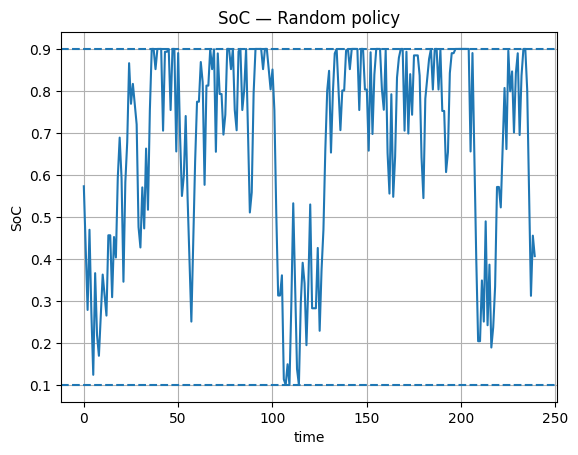

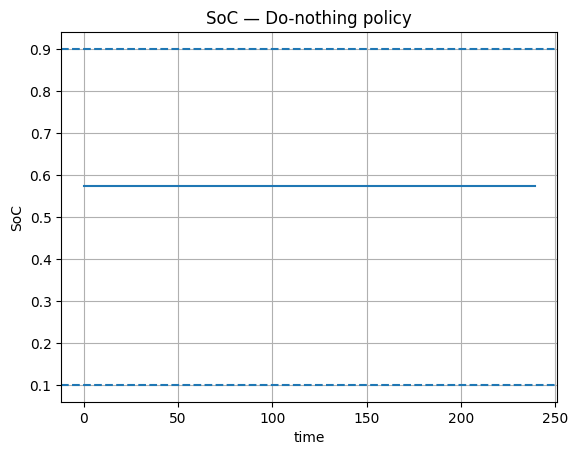

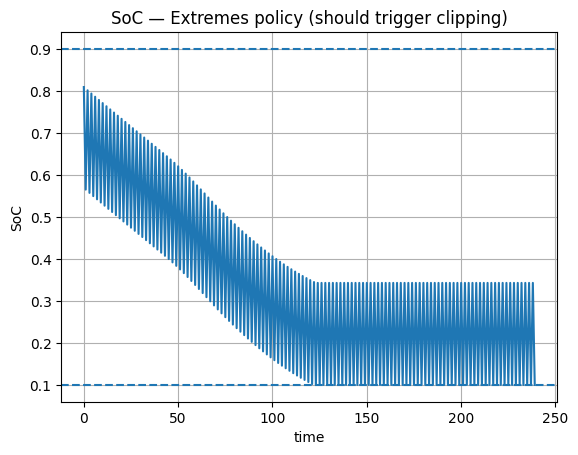

In [6]:
def plot_soc(df, title):
    plt.figure()
    if "delivery_ts" in df.columns:
        x = df["delivery_ts"]
    else:
        x = df["t"]
    plt.plot(x, df["soc"])
    plt.axhline(env.SoC_min, linestyle="--")
    plt.axhline(env.SoC_max, linestyle="--")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("SoC")
    plt.grid(True)
    plt.show()

plot_soc(df_rand, "SoC — Random policy")
plot_soc(df_zero, "SoC — Do-nothing policy")
plot_soc(df_ext,  "SoC — Extremes policy (should trigger clipping)")

## 6. Plot 2: Power request vs applied (clipping visibility)

/var/folders/qb/08dfmxgj7n3b3txg0n902h8c0000gn/T/ipykernel_57416/3677739844.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


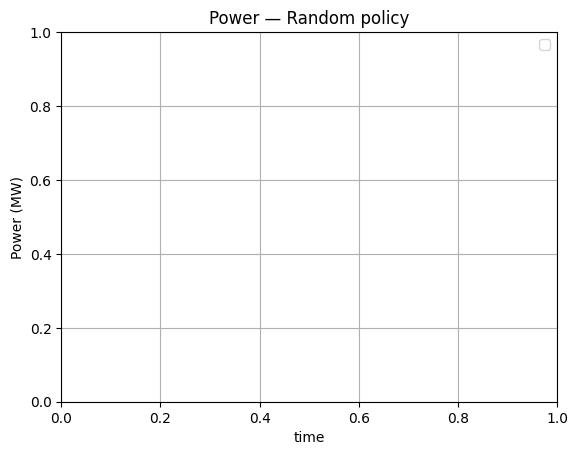

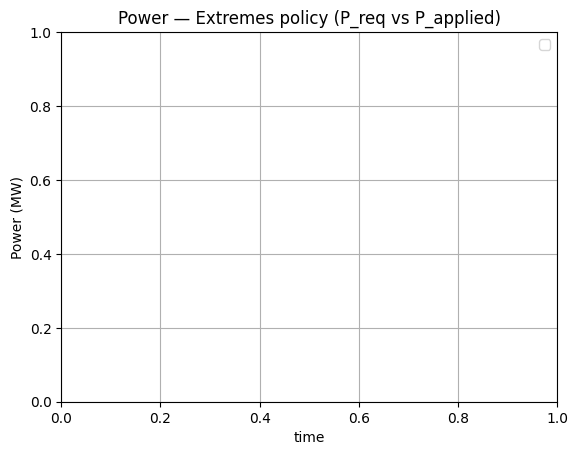

In [7]:
def plot_power_req_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_req_MW" in df.columns:
        plt.plot(x, df["P_req_MW"], label="P_req_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_power_req_vs_applied(df_rand, "Power — Random policy")
plot_power_req_vs_applied(df_ext,  "Power — Extremes policy (P_req vs P_applied)")

## 7. Plot 3: Planned vs applied power

/var/folders/qb/08dfmxgj7n3b3txg0n902h8c0000gn/T/ipykernel_57416/233279253.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


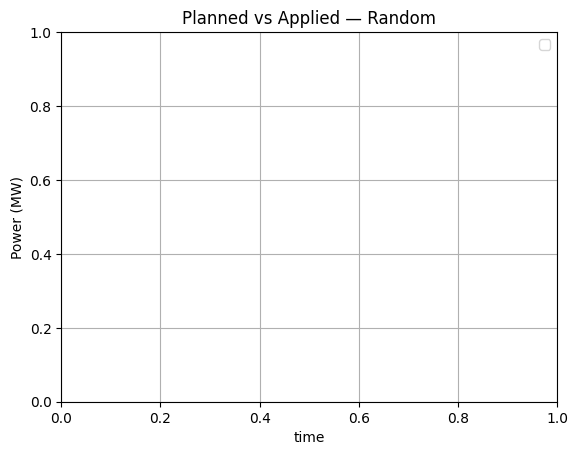

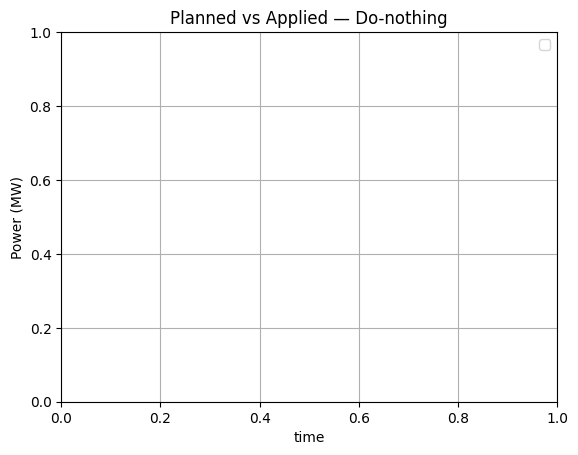

,soc,reward
0,0.572941,0.000000
1,0.425926,0.382756
2,0.278497,0.374775
3,0.469435,-0.377282
4,0.272241,0.486470
5,0.124073,0.369192
6,0.366118,-0.506633
7,0.218666,0.380153
8,0.169351,0.134374
9,0.266528,-0.222231


In [8]:
def plot_planned_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_planned_MW" in df.columns:
        plt.plot(x, df["P_planned_MW"], label="P_planned_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

def planned_vs_applied_table(df, n):
    cols = [
        "delivery_ts",
        "tau",
        "P_planned_MW",
        "P_applied_MW",
        "P_dev_MW",
        "soc",
        "Planned_Profit",
        "Intraday_Profit",
        "carbon_penalty_norm",
        "da_available",
        "reward",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].head(n)



plot_planned_vs_applied(df_rand, "Planned vs Applied — Random")
plot_planned_vs_applied(df_zero, "Planned vs Applied — Do-nothing")
planned_vs_applied_table(df_rand, n=25)

## 8.Plot 4: Prices (DA vs ID) + carbon intensity

/var/folders/qb/08dfmxgj7n3b3txg0n902h8c0000gn/T/ipykernel_57416/3184668354.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


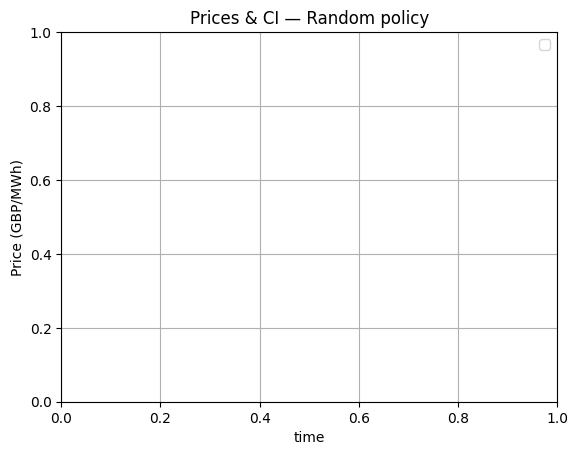

In [9]:
def plot_prices_and_ci(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "id_price_now" in df.columns:
        plt.plot(x, df["id_price_now"], label="ID price")
    if "da_price_now" in df.columns:
        plt.plot(x, df["da_price_now"], label="DA price")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Price (GBP/MWh)")
    plt.grid(True)
    plt.legend()
    plt.show()

    if "ci_now" in df.columns:
        plt.figure()
        plt.plot(x, df["ci_now"])
        plt.title(title + " — Carbon intensity")
        plt.xlabel("time")
        plt.ylabel("CI (gCO2/kWh)")
        plt.grid(True)
        plt.show()

plot_prices_and_ci(df_rand, "Prices & CI — Random policy")

## 9.  Plot 5: DA availability indicator

In [10]:
def plot_da_availability(df, title):
    if "da_available" not in df.columns:
        print("da_available not in df")
        return
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    plt.plot(x, df["da_available"].astype(int))
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("DA available (0/1)")
    plt.grid(True)
    plt.show()

plot_da_availability(df_rand, "DA availability — Random policy")

da_available not in df


## 10. Plot 6: Reward decomposition (profit_norm vs carbon_penalty_norm vs reward)

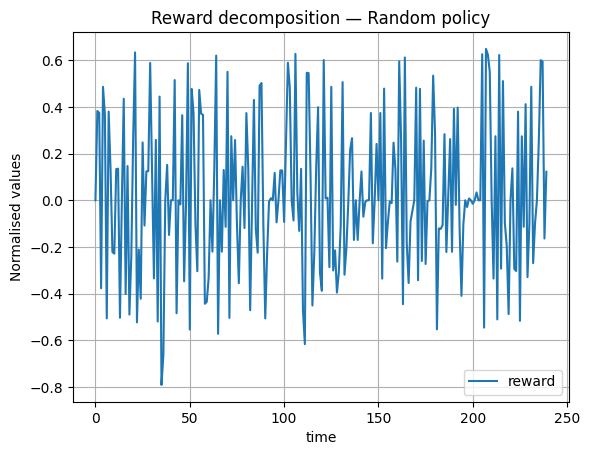

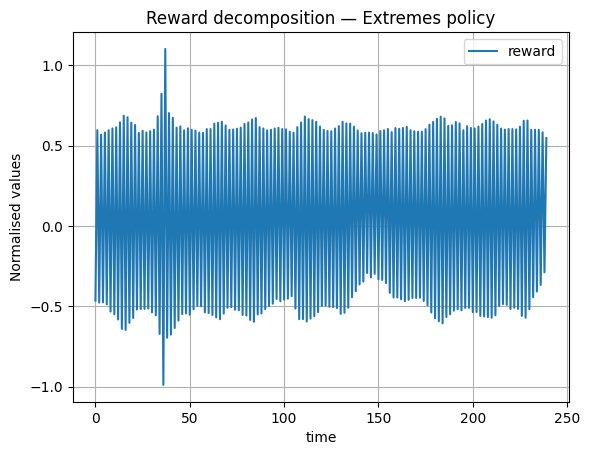

In [11]:
def plot_reward_decomposition(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "profit_norm" in df.columns:
        plt.plot(x, df["profit_norm"], label="profit_norm")
    if "carbon_penalty_norm" in df.columns:
        plt.plot(x, df["carbon_penalty_norm"], label="carbon_penalty_norm")
    plt.plot(x, df["reward"], label="reward")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Normalised values")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_reward_decomposition(df_rand, "Reward decomposition — Random policy")
plot_reward_decomposition(df_ext,  "Reward decomposition — Extremes policy")

## 11. Financial Decomposition

In [12]:
import matplotlib.pyplot as plt

def plot_financial_decomposition(df_rollout, policy_name=""):
    """Plots a stacked bar chart showing Gross Profit vs Degradation."""
    plt.figure(figsize=(14, 6))
    
    # Positive Bars: Gross Market Revenue
    plt.bar(df_rollout['t'], df_rollout['DA_Profit'], 
            label='DA Profit (£)', color='royalblue', alpha=0.8)
    plt.bar(df_rollout['t'], df_rollout['ID_Profit'], 
            bottom=df_rollout['DA_Profit'], 
            label='ID Profit (£)', color='cyan', alpha=0.8)
    
    # Negative Bars: Degradation Cost
    plt.bar(df_rollout['t'], -df_rollout['Degradation_Cost'], 
            label='Degradation Cost (£)', color='crimson', alpha=0.8)
    
    # Line: True Net Margin
    plt.plot(df_rollout['t'], df_rollout['Net_Profit'], 
             label='Net Margin (£)', color='black', linewidth=2, marker='.', markersize=6)
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Financial Decomposition per Step — {policy_name} Policy", fontsize=14)
    plt.xlabel("Step (t)", fontsize=12)
    plt.ylabel("Cashflow (£)", fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

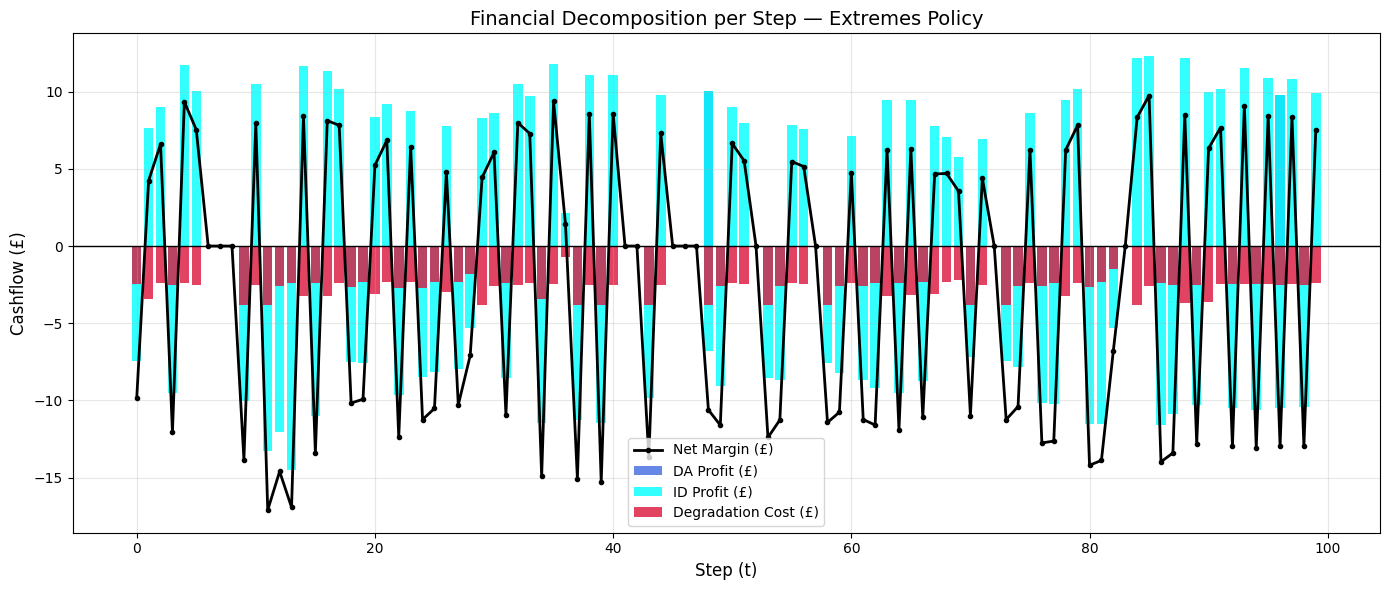

In [13]:
import random

# Define a policy that stresses the battery
def extremes_policy(env, obs, t):
    # Action 0 = Max Charge, Action 10 (or max) = Max Discharge
    extreme_action = random.choice([0, env.n_power_levels - 1])
    return np.array([extreme_action, extreme_action, 0])

# 1. Collect the data using the function we just added
df_extremes = collect_steps(env, n_steps=100, policy_fn=extremes_policy, seed=42)

# 2. Plot the data!
plot_financial_decomposition(df_extremes, policy_name="Extremes")

## 11. Plot 7: clipping histogram + applied power distribution

<Figure size 640x480 with 0 Axes>

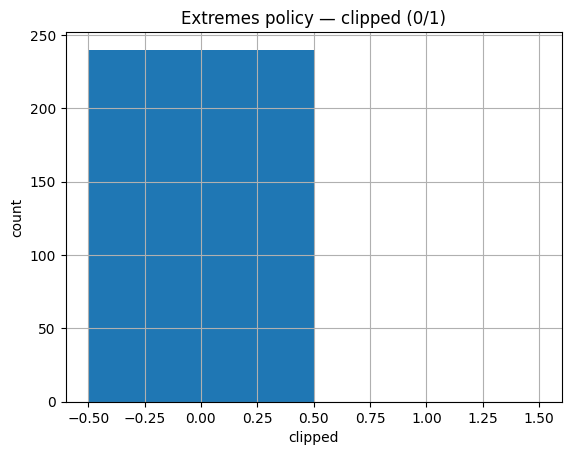

In [14]:
def plot_distributions(df, title):
    plt.figure()
    if "P_applied_MW" in df.columns:
        plt.hist(df["P_applied_MW"].dropna().to_numpy(), bins=40)
        plt.title(title + " — P_applied distribution")
        plt.xlabel("P_applied_MW")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

    if "clipped" in df.columns:
        plt.figure()
        plt.hist(df["clipped"].astype(int).to_numpy(), bins=[-0.5,0.5,1.5])
        plt.title(title + " — clipped (0/1)")
        plt.xlabel("clipped")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

plot_distributions(df_ext, "Extremes policy")

# Summary

In [15]:
summary = pd.DataFrame([
    {"policy": "random", **metrics(df_rand)},
    {"policy": "do_nothing", **metrics(df_zero)},
    {"policy": "extremes", **metrics(df_ext)},
])
summary

,policy,soc_min,soc_max,clip_rate,mean_reward
0,random,0.100000,0.900000,0.0,0.021366
1,do_nothing,0.572941,0.572941,0.0,0.000000
2,extremes,0.100000,0.809261,0.0,0.053274


# DA Planning Test Logic

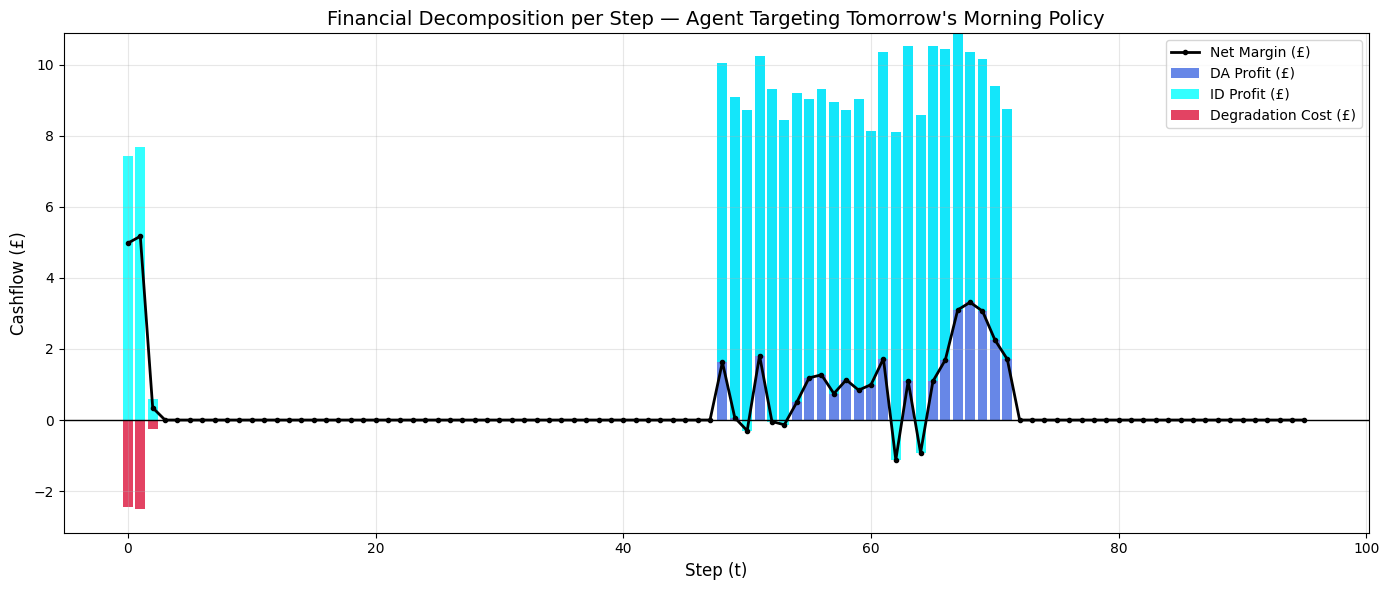

In [17]:
def da_heavy_policy_morning_target(env, obs, t):
    """
    This agent uses its 24 unlocked afternoon steps (12:00 PM to 11:30 PM) 
    to explicitly fill up tomorrow's MORNING slots (Midnight to 11:30 AM).
    """
    max_idx = env.n_power_levels - 1
    
    # Get the current half-hour of the current day (0 to 47)
    current_step_of_day = t % 48
    
    # MAP: 
    # At 12:00 PM (step 24), write to Tomorrow Slot 0 (Midnight)
    # At 11:30 PM (step 47), write to Tomorrow Slot 23 (11:30 AM)
    target_plan_slot = (current_step_of_day - 24) % 48
    
    return np.array([max_idx, max_idx, target_plan_slot])

# Rollout exactly 96 steps (2 full days)
df_da = collect_steps(env, n_steps=96, policy_fn=da_heavy_policy_morning_target, seed=42)

# Plot the financial transition!
plot_financial_decomposition(df_da, policy_name="Agent Targeting Tomorrow's Morning")